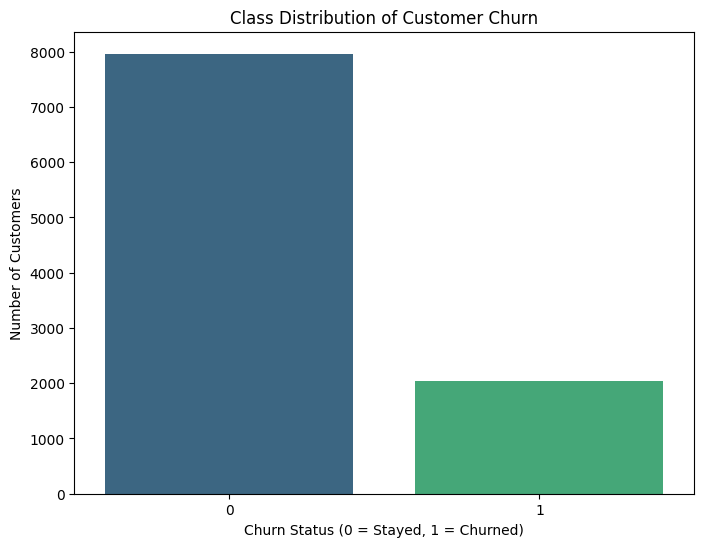

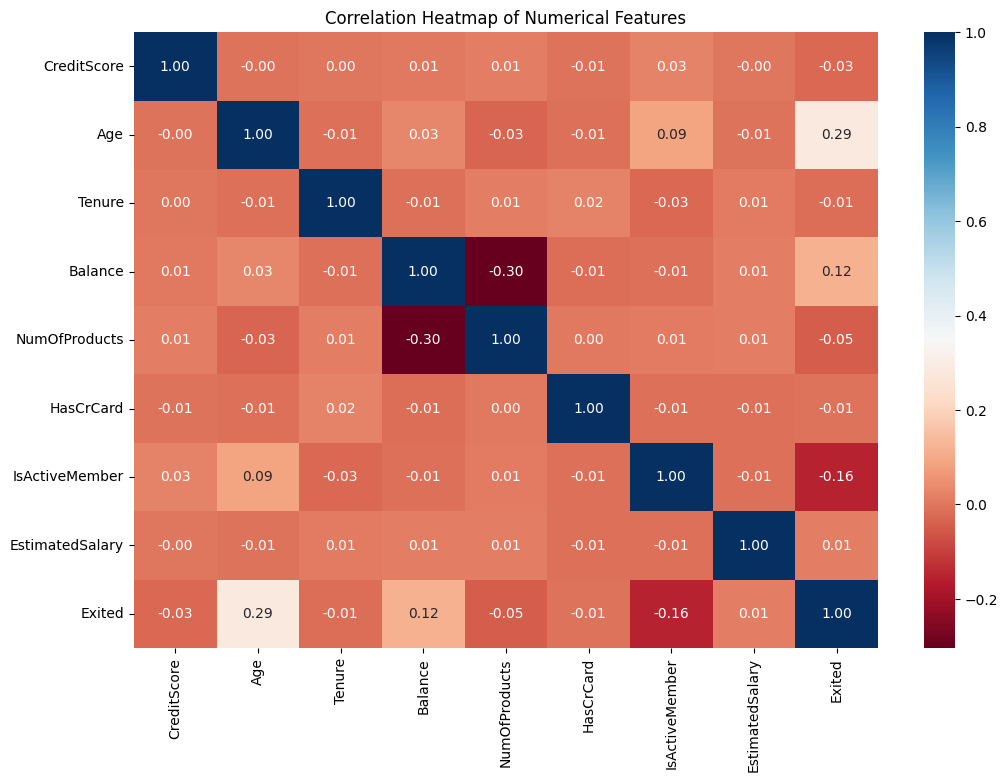

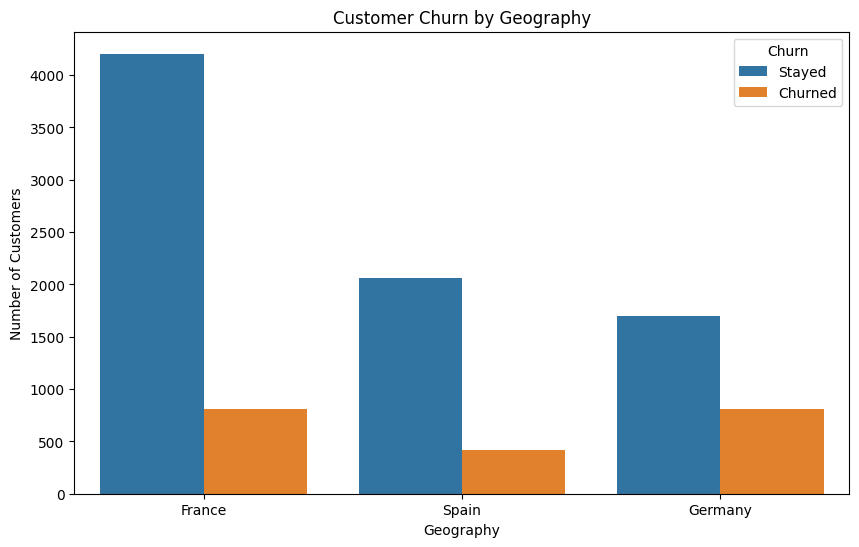

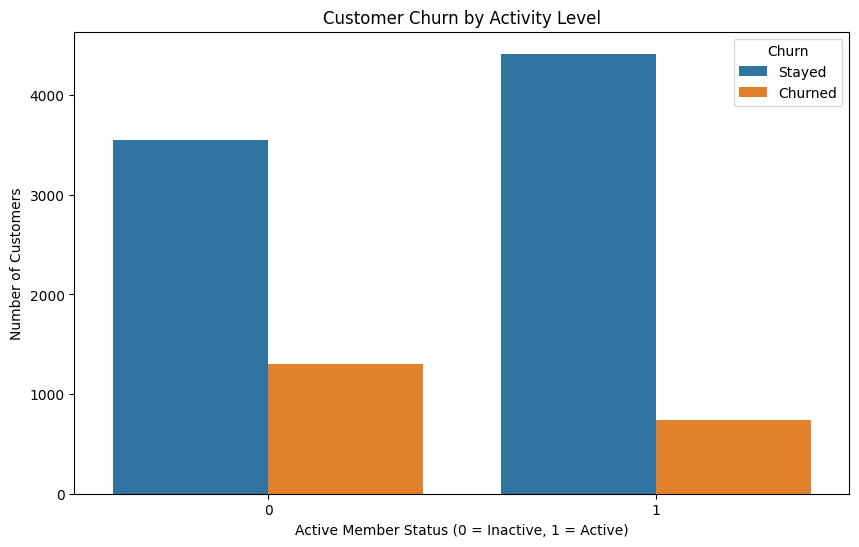

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure your dataframe 'df' is loaded and initial drops are done
df = pd.read_csv("Churn_Modelling.csv")
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

# Figure 1: Churn Class Balance
# Shows the 80/20 split between stayed and churned customers
plt.figure(figsize=(8, 6))
sns.countplot(x='Exited', data=df, palette='viridis', hue='Exited', legend=False)
plt.title('Class Distribution of Customer Churn')
plt.xlabel('Churn Status (0 = Stayed, 1 = Churned)')
plt.ylabel('Number of Customers')
plt.show()

# Figure 2: Correlation Heatmap
# Shows relationships between numerical features like Age and Balance
plt.figure(figsize=(12, 8))
# Only include numerical columns for the correlation matrix
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='RdBu', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

# Figure 3: Churn by Geography
# Shows how location (Germany, France, Spain) impacts churn rates
plt.figure(figsize=(10, 6))
sns.countplot(x='Geography', hue='Exited', data=df)
plt.title('Customer Churn by Geography')
plt.xlabel('Geography')
plt.ylabel('Number of Customers')
plt.legend(title='Churn', labels=['Stayed', 'Churned'])
plt.show()

# Figure 4: Churn by Activity Level
# Shows that inactive members (0) are significantly more likely to leave
plt.figure(figsize=(10, 6))
sns.countplot(x='IsActiveMember', hue='Exited', data=df)
plt.title('Customer Churn by Activity Level')
plt.xlabel('Active Member Status (0 = Inactive, 1 = Active)')
plt.ylabel('Number of Customers')
plt.legend(title='Churn', labels=['Stayed', 'Churned'])
plt.show()

Final Model Accuracy: 81.1%


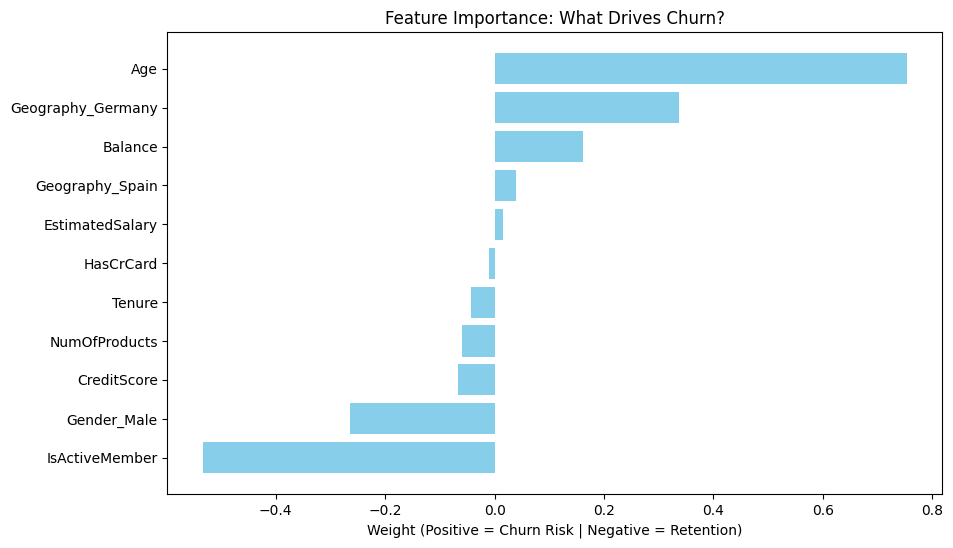

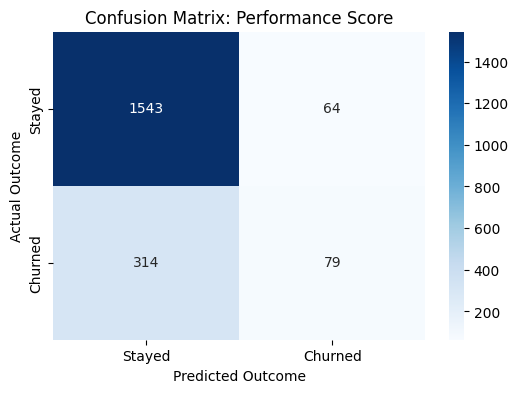


Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.96      0.89      1607
           1       0.55      0.20      0.29       393

    accuracy                           0.81      2000
   macro avg       0.69      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000



In [2]:
!pip install lime

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import lime
from lime import lime_tabular

# Import the data and clean up the unneeded columns
df = pd.read_csv("Churn_Modelling.csv")
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

# Turn the text categories into numbers the model can read
df = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True)

# Separate the features from the target goal
X = df.drop('Exited', axis=1)
y = df['Exited']

# Break the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the scales so factors like age and balance are weighted fairly
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize and train the logistic regression model
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

# Calculate the final accuracy percentage
predictions = lr_model.predict(X_test_scaled)
print(f"Final Model Accuracy: {accuracy_score(y_test, predictions) * 100:.1f}%")

# Create a bar chart to see which features impact churn the most
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': lr_model.coef_[0]
}).sort_values(by='Importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(feature_importances['Feature'], feature_importances['Importance'], color='skyblue')
plt.title('Feature Importance: What Drives Churn?')
plt.xlabel('Weight (Positive = Churn Risk | Negative = Retention)')
plt.show()

# Generate a confusion matrix to get a deeper performance score
cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'])
plt.title('Confusion Matrix: Performance Score')
plt.ylabel('Actual Outcome')
plt.xlabel('Predicted Outcome')
plt.show()

# Print the full classification report for precision and recall
print("\nDetailed Classification Report:")
print(classification_report(y_test, predictions))

# Set up the LIME explainer for auditing individual cases
explainer = lime_tabular.LimeTabularExplainer(
    training_data=X_train_scaled,
    feature_names=X.columns.tolist(),
    class_names=['Stayed', 'Churned'],
    mode='classification'
)

# Run an audit on a specific instance to see why the model made its choice
exp = explainer.explain_instance(
    data_row=X_test_scaled[15],
    predict_fn=lr_model.predict_proba
)
exp.show_in_notebook(show_table=True)

In [3]:
from sklearn.metrics import accuracy_score

y_pred = lr_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"My Real Model Accuracy: {accuracy * 100:.1f}%")

My Real Model Accuracy: 19.9%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


In [4]:
import pandas as pd

# Match the features to their weights in the model
feature_importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': lr_model.coef_[0]
})

# Sort them from most negative (Retention) to most positive (Churn risk)
feature_importances = feature_importances.sort_values(by='Importance', ascending=False)
print(feature_importances)

              Feature  Importance
1                 Age    0.754217
8   Geography_Germany    0.337190
3             Balance    0.161139
9     Geography_Spain    0.038960
7     EstimatedSalary    0.015744
5           HasCrCard   -0.010236
2              Tenure   -0.042637
4       NumOfProducts   -0.060278
0         CreditScore   -0.067683
10        Gender_Male   -0.264718
6      IsActiveMember   -0.533432
